# 1. Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint
)
from tensorflow.keras.callbacks import ReduceLROnPlateau

# 2. Dataset Path

In [3]:
DATA_PATH = r"D:\master\02- Second Semester\04- AI\Project\EuroSAT_MS\Processed_Data\RGB"

print("Dataset Path:")
print(DATA_PATH)

Dataset Path:
D:\master\02- Second Semester\04- AI\Project\EuroSAT_MS\Processed_Data\RGB


# 3. Load Dataset

In [4]:
X = []
y = []

classes = sorted(os.listdir(DATA_PATH))
for class_name in classes:
    class_path = os.path.join(
        DATA_PATH,
        class_name
    )

    if not os.path.isdir(class_path):
        continue
    for file in os.listdir(class_path):
        if not file.endswith(".npy"):
            continue
        image = np.load(
            os.path.join(
                class_path,
                file
            )
        )
        X.append(image)
        y.append(class_name)

X = np.array(X)
y = np.array(y)

print("Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)

Dataset Shape: (54000, 64, 64, 3)
Labels Shape: (54000,)


# 4. Encode Labels

In [5]:
encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

print("Classes:")
print(encoder.classes_)

num_classes = len(
    encoder.classes_
)

print("Number of Classes:", num_classes)

Classes:
['AnnualCrop' 'Forest' 'HerbaceousVegetation' 'Highway' 'Industrial'
 'Pasture' 'PermanentCrop' 'Residential' 'River' 'SeaLake']
Number of Classes: 10


# 5. Split data into (Train / Validation / Test)

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (37800, 64, 64, 3)
Validation: (8100, 64, 64, 3)
Test: (8100, 64, 64, 3)


# 6. CNN Architecture

In [7]:
model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(64,64,3)
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        num_classes,
        activation='softmax'
    )

])

model.summary()

c:\Users\Asmaa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 685,386 (2.61 MB)

 Trainable params: 684,938 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

# 7. Compile Model

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 8. Train Model

In [12]:
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_rgb_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

In [13]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=100,

    batch_size=32,

    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/100
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.4675 - loss: 1.7429
Epoch 1: val_accuracy improved from -inf to 0.72457, saving model to best_rgb_model.keras
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 108s 89ms/step - accuracy: 0.4676 - loss: 1.7426 - val_accuracy: 0.7246 - val_loss: 0.8129 - learning_rate: 0.0010
Epoch 2/100
1181/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.6512 - loss: 1.0121
Epoch 2: val_accuracy improved from 0.72457 to 0.74531, saving model to best_rgb_model.keras
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 103s 87ms/step - accuracy: 0.6513 - loss: 1.0120 - val_accuracy: 0.7453 - val_loss: 0.7742 - learning_rate: 0.0010
Epoch 3/100
1181/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.7372 - loss: 0.7940
Epoch 3: val_accuracy did not improve from 0.74531
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 105s 89ms/step - accuracy: 0.7372 - loss: 0.7939 - val_accuracy: 0.4423 - val_loss: 3.8867 - learning_rate: 0.0010
Epoch 4/100
1181/1182 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - 

# 9. Evaluate Model

In [14]:
test_loss, test_acc = model.evaluate(
    X_test,
    y_test
)

print( f"Test Accuracy = {test_acc:.4f}")

254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9522 - loss: 0.2109
Test Accuracy = 0.9519


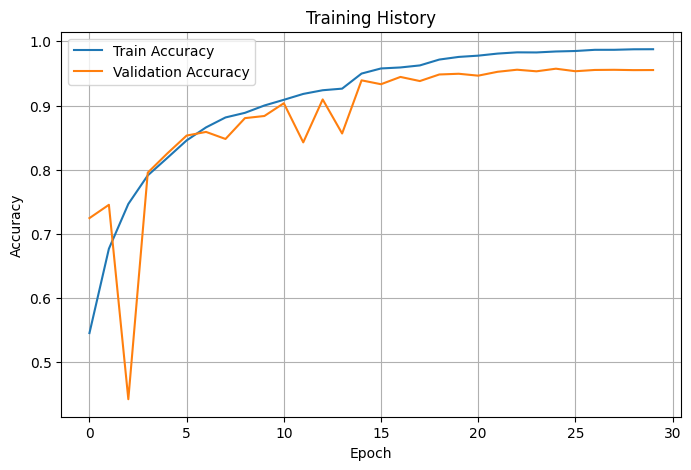

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training History")
plt.legend()
plt.grid()
plt.show()

In [16]:
y_pred = model.predict(X_test)

y_pred = np.argmax(
    y_pred,
    axis=1
)

254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step


In [17]:
print(classification_report(y_test, y_pred, target_names=encoder.classes_ ))

                      precision    recall  f1-score   support

          AnnualCrop       0.96      0.93      0.95       900
              Forest       0.99      0.99      0.99       900
HerbaceousVegetation       0.91      0.92      0.91       900
             Highway       0.95      0.94      0.94       750
          Industrial       0.93      0.97      0.95       750
             Pasture       0.96      0.94      0.95       600
       PermanentCrop       0.91      0.90      0.91       750
         Residential       0.97      0.99      0.98       900
               River       0.94      0.94      0.94       750
             SeaLake       0.99      0.99      0.99       900

            accuracy                           0.95      8100
           macro avg       0.95      0.95      0.95      8100
        weighted avg       0.95      0.95      0.95      8100



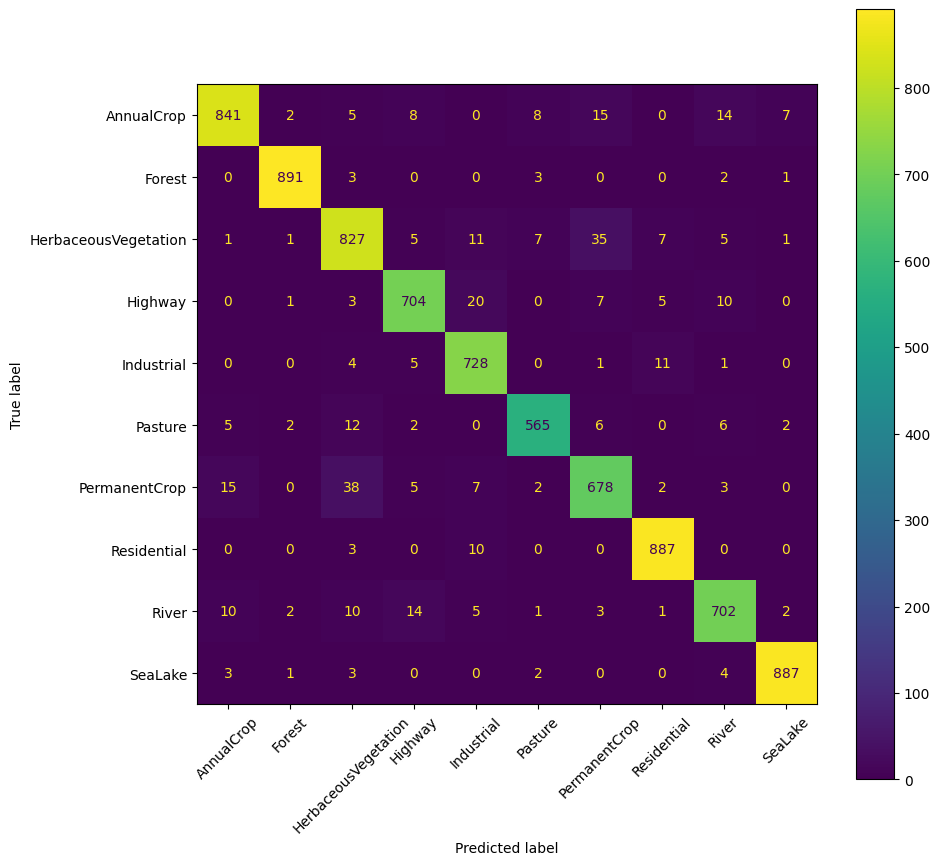

In [18]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_)

fig, ax = plt.subplots(figsize=(10,10))

disp.plot(ax=ax,xticks_rotation=45)
plt.show()